# Module 2 — Emotion Classifier

**Goal:** Build a multi-class emotion classifier that detects the user's emotional state from their input text. The predicted emotion is used downstream to tailor the chatbot's response tone and style.

**Dataset:** [dair-ai/emotion](https://huggingface.co/datasets/dair-ai/emotion) — both `split` and `unsplit` versions combined.

**Models:** Vanilla RNN · GRU · LSTM · DistilBERT (Transformer)

---
## 0. Install & Import Dependencies

In [1]:
!pip install datasets transformers tokenizers --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

# HuggingFace
from datasets import load_dataset, concatenate_datasets

# NTLK
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Device : cuda
PyTorch: 2.11.0+cu128


In [3]:
# Mount my drive to import GloVe embeddings from it
from google.colab import drive
drive.mount('/content/drive')

# Create a directory to store the artifacts
os.makedirs('artifacts', exist_ok=True)

Mounted at /content/drive


---
## 1. Load & Combine Dataset

In [4]:
# Load both versions
ds_split   = load_dataset('dair-ai/emotion', 'split')
ds_unsplit = load_dataset('dair-ai/emotion', 'unsplit')

print("Split version:")
print(ds_split)
print("\nUnsplit version:")
print(ds_unsplit)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

unsplit/train-00000-of-00001.parquet:   0%|          | 0.00/26.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/416809 [00:00<?, ? examples/s]

Split version:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Unsplit version:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 416809
    })
})


In [5]:
# Collect all data from both versions into one pool
all_splits = []

for split_name in ds_split.keys():
    all_splits.append(ds_split[split_name])

for split_name in ds_unsplit.keys():
    all_splits.append(ds_unsplit[split_name])

combined = concatenate_datasets(all_splits)
print(f"Combined size before deduplication: {len(combined)}")

Combined size before deduplication: 436809


In [6]:
# Convert to DataFrame and deduplicate on text
df = combined.to_pandas()
print(f"Before deduplication: {len(df)}")
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f"After deduplication : {len(df)}")
df.head()

Before deduplication: 436809
After deduplication : 393822


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [7]:
# Decode integer labels to emotion names
# dair-ai/emotion label mapping
label2emotion = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
df['emotion'] = df['label'].map(label2emotion)

print("Label mapping:", label2emotion)
print()
print(((df['emotion'].value_counts() / df.shape[0]) * 100).round(2))

Label mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

emotion
joy         34.30
sadness     30.09
anger       13.89
fear        11.09
love         7.47
surprise     3.16
Name: count, dtype: float64


In [8]:
# Train / Validation / Test split (90 / 5 / 5)
# Stratified to preserve class distribution
train_df, temp_df = train_test_split(
    df, test_size=0.10, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

Train : 354439
Val   : 19691
Test  : 19692


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

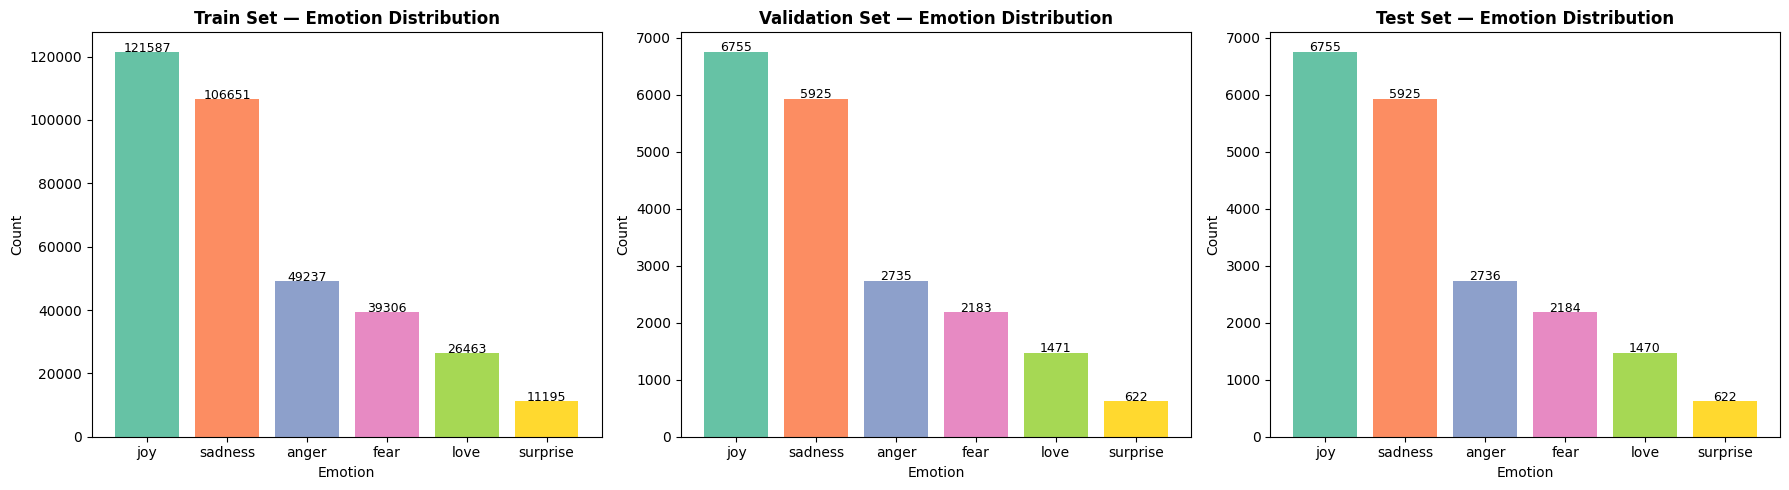


Class imbalance ratio in training data (max / min): 10.86x


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette('Set2', 6)

for ax, (split_df, name) in zip(axes, [(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]):
    counts = split_df['emotion'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=palette)
    ax.set_title(f'{name} Set — Emotion Distribution', fontweight='bold')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./artifacts/emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

counts = train_df['emotion'].value_counts()
print(f"\nClass imbalance ratio in training data (max / min): {counts.max() / counts.min():.2f}x")

### 2.2 Text Length Analysis

In [10]:
train_df['word_count'] = train_df['text'].str.split().str.len()
train_df['char_count'] = train_df['text'].str.len()

print("=== Text Length Stats (Train) ===")
print(train_df[['word_count', 'char_count']].describe().round(2))

=== Text Length Stats (Train) ===
       word_count  char_count
count   354439.00   354439.00
mean        19.19       96.93
std         11.04       56.14
min          1.00        2.00
25%         11.00       54.00
50%         17.00       86.00
75%         25.00      128.00
max        178.00      830.00


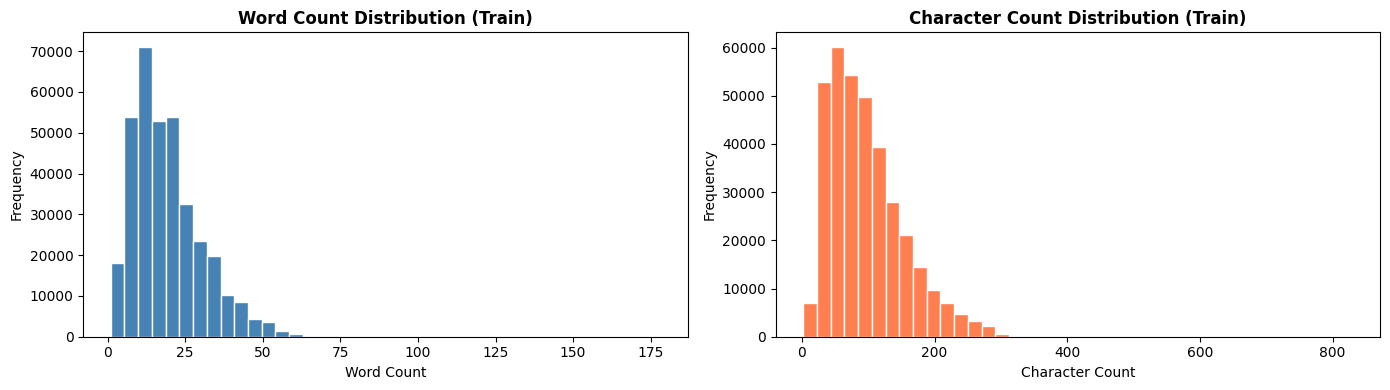

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['word_count'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Word Count Distribution (Train)', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(train_df['char_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Character Count Distribution (Train)', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('./artifacts/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

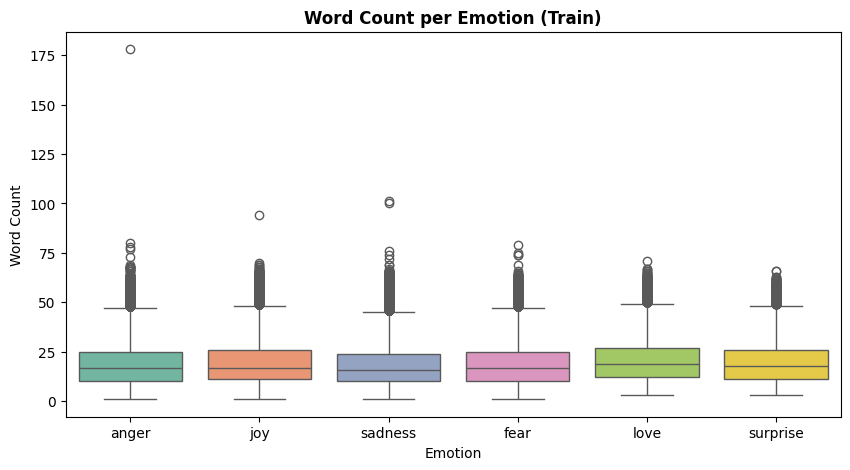

In [12]:
# Word count per emotion
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df, x='emotion', y='word_count', palette='Set2')
plt.title('Word Count per Emotion (Train)', fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.savefig('./artifacts/word_count_per_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Most Common Words per Emotion

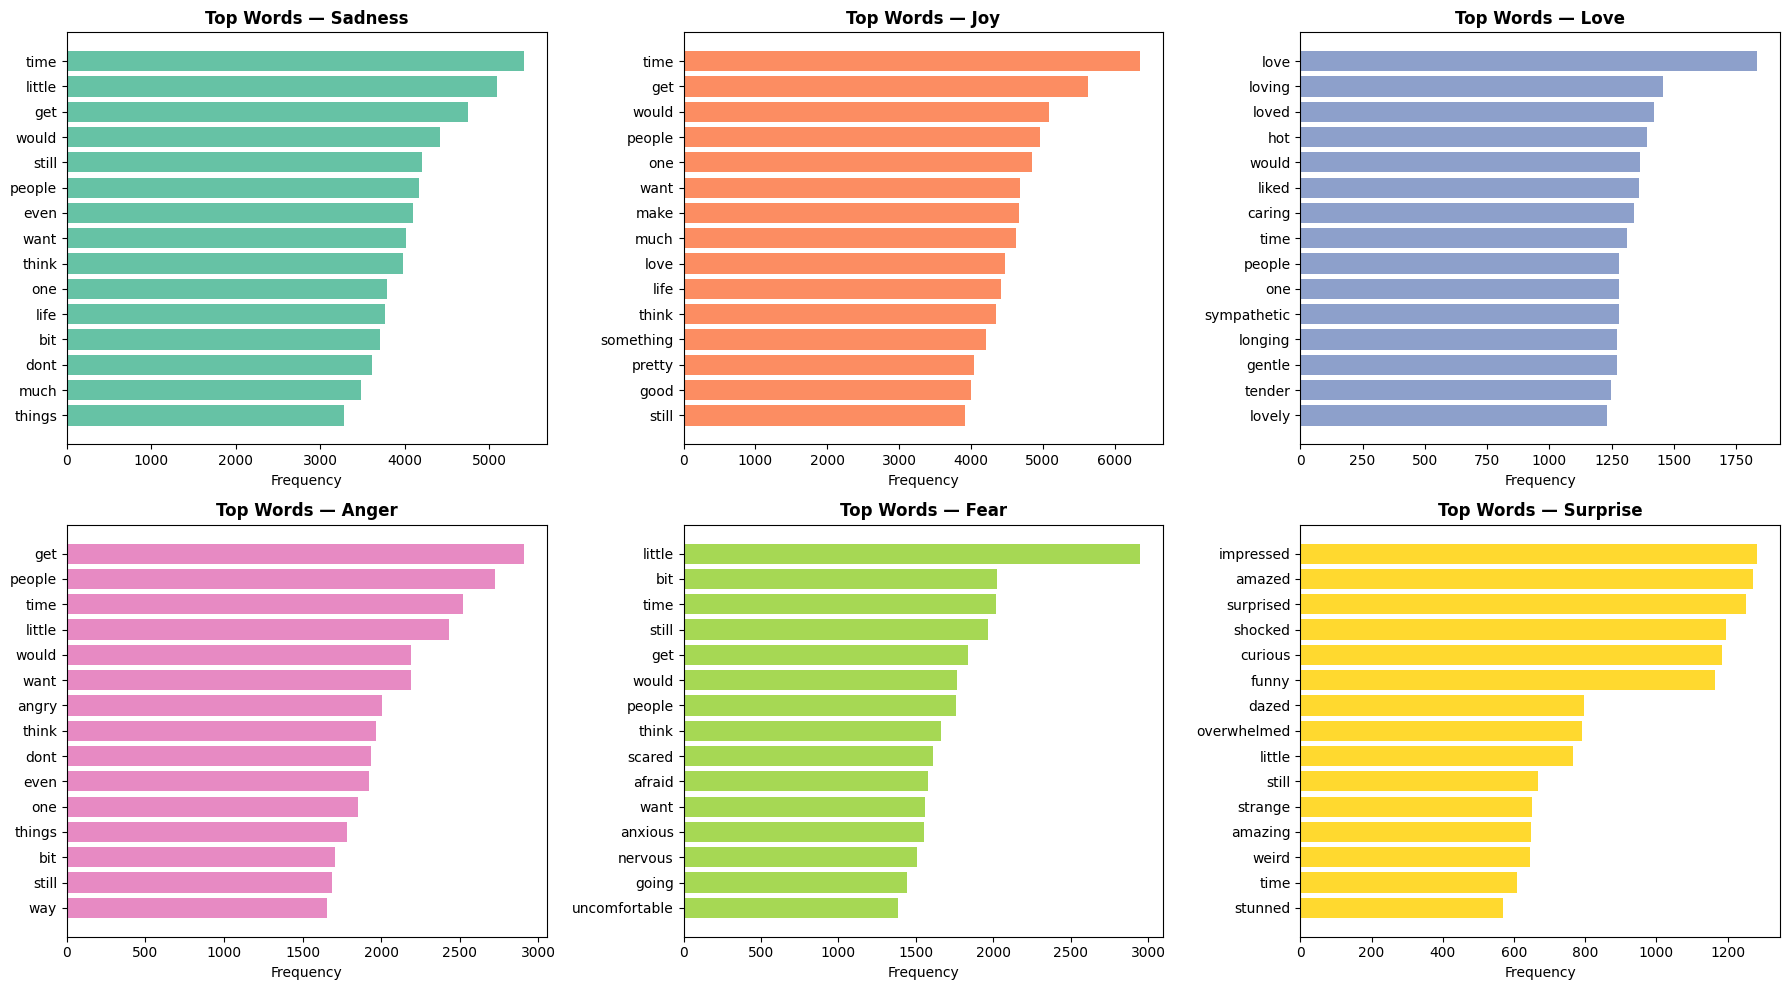

In [13]:
STOPWORDS = set(stopwords.words('english'))
STOPWORDS.update(['feel', 'feeling', 'felt', 'just', 'really', 'im', 'like',
                  'ive', 'know'])

emotions = list(label2emotion.values())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, emotion in zip(axes.flatten(), emotions):
    texts = train_df[train_df['emotion'] == emotion]['text'].str.lower().str.split()
    words = [w for tokens in texts for w in tokens if w not in STOPWORDS and w.isalpha()]
    common = Counter(words).most_common(15)
    words_plot, counts_plot = zip(*common)
    ax.barh(words_plot[::-1], counts_plot[::-1], color=sns.color_palette('Set2', 6)[emotions.index(emotion)])
    ax.set_title(f'Top Words — {emotion.capitalize()}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('./artifacts/top_words_per_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Sample Texts per Emotion

In [14]:
print("=== Sample texts per emotion ===")
for emotion in emotions:
    sample = train_df[train_df['emotion'] == emotion]['text'].iloc[0]
    print(f"{emotion:<10} {sample}\n")

=== Sample texts per emotion ===
sadness    i feel thoroughly rotten

joy        im just feeling more casual and flirty

love       i don t know how to give him that and i feel i ve been robbed of the ability to truly be affectionate with him

anger      i have been feeling really frustrated with our bedroom

fear       i know we have that many couples don t have the ability to talk about everything including our sex life and how we feel when one of us me in this instance feels vulnerable

surprise   i uh i found it by typing in i feel dazed and emotionless and very worried ive wrote a poem about feeling this way too



---
## 3. Preprocessing

> **Design Decision:** Emotion classification benefits from **moderate preprocessing** — we preserve sentiment-carrying words (negations, intensifiers) and avoid stemming which can destroy emotional nuance. We apply different preprocessing for:
> - **RNN/GRU/LSTM**: tokenize + build vocab + map to GloVe embeddings
> - **DistilBERT**: use its own WordPiece tokenizer (no manual preprocessing needed)

In [15]:
def clean_text(text: str) -> str:
    """
    Light cleaning for RNN-based models:
    - Lowercase
    - Remove URLs, mentions, hashtags
    - Remove special characters (keep apostrophes for contractions)
    - Normalize whitespace
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)           # URLs
    text = re.sub(r'@\w+|#\w+', '', text)                # mentions & hashtags
    text = re.sub(r"[^a-z0-9'\s]", '', text)             # keep letters, digits, apostrophes
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to all splits
for df in [train_df, val_df, test_df]:
    df['text_clean'] = df['text'].apply(clean_text)

# Verify
print("Before:", train_df['text'].iloc[0])
print("After :", train_df['text_clean'].iloc[0])

Before: i have been feeling really frustrated with our bedroom
After : i have been feeling really frustrated with our bedroom


### 3.1 Build Vocabulary

In [16]:
# Build vocabulary from training set only
MIN_FREQ = 2  # ignore very rare words

word_freq = Counter()
for text in train_df['text_clean']:
    word_freq.update(text.split())

# Special tokens
PAD_TOKEN = '<PAD>'  # index 0
UNK_TOKEN = '<UNK>'  # index 1

vocab = [PAD_TOKEN, UNK_TOKEN] + [
    word for word, freq in word_freq.items() if freq >= MIN_FREQ
]
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx[PAD_TOKEN]
UNK_IDX    = word2idx[UNK_TOKEN]

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"PAD index       : {PAD_IDX}")
print(f"UNK index       : {UNK_IDX}")

Vocabulary size : 36753
PAD index       : 0
UNK index       : 1


### 3.2 Determine Max Sequence Length

In [17]:
lengths = train_df['text_clean'].str.split().str.len()
print(f"90th percentile length: {int(np.percentile(lengths, 90))} words")
print(f"95th percentile length: {int(np.percentile(lengths, 95))} words")
print(f"99th percentile length: {int(np.percentile(lengths, 99))} words")
print(f"Max length            : {lengths.max()} words")

# Use 95th percentile to avoid padding too much
MAX_LEN = int(np.percentile(lengths, 95))
print(f"\nUsing MAX_LEN = {MAX_LEN}")

90th percentile length: 35 words
95th percentile length: 41 words
99th percentile length: 52 words
Max length            : 178 words

Using MAX_LEN = 41


### 3.3 Load GloVe Embeddings

In [18]:
# GloVe 6B 100d file is uploaded to my drive

GLOVE_PATH = '/content/drive/MyDrive/GloVe/glove.6B.100d.txt'
EMBED_DIM  = 100

# Check if file exists; if not, provide instructions
if not os.path.exists(GLOVE_PATH):
    print("GloVe file not found.")
    print("On Kaggle: Add dataset 'GloVe 6B' from the dataset panel.")
    print("Then update GLOVE_PATH to point to 'glove.6B.100d.txt'.")
else:
    print(f"GloVe file found at: {GLOVE_PATH}")

GloVe file found at: /content/drive/MyDrive/GloVe/glove.6B.100d.txt


In [19]:
def load_glove(glove_path: str, word2idx: dict, embed_dim: int) -> torch.Tensor:
    """
    Load GloVe vectors for words in our vocabulary.
    Words not found in GloVe are randomly initialized.
    PAD vector stays all zeros.
    """
    NUM_GloVe_LINES = 400000
    vocab_size = len(word2idx)
    # Random init for all (handles OOV words)
    embedding_matrix = torch.randn(vocab_size, embed_dim) * 0.01
    # PAD stays zero
    embedding_matrix[PAD_IDX] = torch.zeros(embed_dim)

    found = 0
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=NUM_GloVe_LINES, desc="GloVe Embeddings"):
            parts = line.strip().split()
            word  = parts[0]
            if word in word2idx:
                vector = torch.tensor([float(x) for x in parts[1:]], dtype=torch.float)
                embedding_matrix[word2idx[word]] = vector
                found += 1

    print(f"GloVe coverage: {found} / {vocab_size} words ({found/vocab_size*100:.1f}%)")
    return embedding_matrix

embedding_matrix = load_glove(GLOVE_PATH, word2idx, EMBED_DIM)

GloVe Embeddings:   0%|          | 0/400000 [00:00<?, ?it/s]

GloVe coverage: 34459 / 36753 words (93.8%)


### 3.4 PyTorch Datasets

In [25]:
def text_to_indices(text: str, word2idx: dict, max_len: int) -> list:
    """Tokenize text, map to indices, truncate/pad to max_len."""
    tokens = text.split()[:max_len]
    indices = [word2idx.get(t, UNK_IDX) for t in tokens]
    # Pad
    indices += [PAD_IDX] * (max_len - len(indices))
    return indices


class EmotionDatasetRNN(Dataset):
    """Dataset for RNN/GRU/LSTM models."""
    def __init__(self, df, word2idx, max_len):
        self.texts  = df['text_clean'].tolist()
        self.labels = df['label'].tolist()
        self.word2idx = word2idx
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        indices = text_to_indices(self.texts[idx], self.word2idx, self.max_len)
        return (
            torch.tensor(indices, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


class EmotionDatasetBERT(Dataset):
    """Dataset for DistilBERT."""
    def __init__(self, df, tokenizer, max_len):
        self.texts     = df['text'].tolist()   # use original text for BERT
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE    = 64
BERT_MAX_LEN  = MAX_LEN   # 95% precentile
NUM_CLASSES   = 6

# RNN DataLoaders
train_rnn = EmotionDatasetRNN(train_df, word2idx, MAX_LEN)
val_rnn   = EmotionDatasetRNN(val_df,   word2idx, MAX_LEN)
test_rnn  = EmotionDatasetRNN(test_df,  word2idx, MAX_LEN)

train_loader_rnn = DataLoader(train_rnn, batch_size=BATCH_SIZE, shuffle=True)
val_loader_rnn   = DataLoader(val_rnn,   batch_size=BATCH_SIZE)
test_loader_rnn  = DataLoader(test_rnn,  batch_size=BATCH_SIZE)

# BERT DataLoaders
bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_bert = EmotionDatasetBERT(train_df, bert_tokenizer, BERT_MAX_LEN)
val_bert   = EmotionDatasetBERT(val_df,   bert_tokenizer, BERT_MAX_LEN)
test_bert  = EmotionDatasetBERT(test_df,  bert_tokenizer, BERT_MAX_LEN)

train_loader_bert = DataLoader(train_bert, batch_size=BATCH_SIZE, shuffle=True)
val_loader_bert   = DataLoader(val_bert,   batch_size=BATCH_SIZE)
test_loader_bert  = DataLoader(test_bert,  batch_size=BATCH_SIZE)

print("DataLoaders ready ✓")

DataLoaders ready ✓


### 3.5 Class Weights for Imbalance

In [26]:
from torch import Tensor

# Compute inverse-frequency class weights from training set
label_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / torch.tensor(label_counts.values, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalize
class_weights = class_weights.to(DEVICE)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {label2emotion[i]:<10}: {w:.4f}")

Class weights:
  sadness   : 0.2954
  joy       : 0.2591
  love      : 1.1904
  anger     : 0.6398
  fear      : 0.8014
  surprise  : 2.8139


---
## 4. Model Definitions

In [27]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, rnn_type='RNN',
                 pretrained_embeddings=None, pad_idx=0):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(pretrained_embeddings)
            self.embedding.weight.requires_grad = True  # fine-tune embeddings

        self.dropout = nn.Dropout(dropout)

        rnn_cls = {'RNN': nn.RNN, 'GRU': nn.GRU, 'LSTM': nn.LSTM}[rnn_type]
        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        self.rnn_type = rnn_type

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))    # (B, L, E)
        output, hidden = self.rnn(embedded) if self.rnn_type != 'LSTM' \
                         else self.rnn(embedded)[:2]

        if self.rnn_type == 'LSTM':
            hidden = hidden[0]  # (num_layers, B, H)

        # Take last layer's hidden state
        last_hidden = hidden[-1]  # (B, H)
        return self.fc(last_hidden)


print("RNNClassifier defined ✓")

RNNClassifier defined ✓


---
## 5. Training Utilities

In [31]:
def train_epoch_rnn(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


def eval_epoch_rnn(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(DEVICE), labels.to(DEVICE)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, correct / total, f1


def train_epoch_bert(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


def eval_epoch_bert(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, correct / total, f1


def plot_training_curves(history: dict, model_name: str):
    """Plot train vs validation loss on the same graph."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='steelblue')
    ax.plot(epochs, history['val_loss'],   's--', label='Val Loss',   color='coral')
    ax.set_title(f'Training & Validation Loss — {model_name}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = f"./artifacts/loss_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


print("Training utilities defined ✓")

Training utilities defined ✓


---
## 6. Train RNN Models

We train Vanilla RNN, GRU, and LSTM using the same architecture and hyperparameters for a fair comparison.


 Training RNN
Epoch 01/15 | Train Loss: 1.6933 Acc: 0.2418 | Val Loss: 1.4318 Acc: 0.2511 F1: 0.1831 | 36.3s
Epoch 02/15 | Train Loss: 1.3563 Acc: 0.3175 | Val Loss: 1.0617 Acc: 0.5578 F1: 0.3725 | 39.8s
Epoch 03/15 | Train Loss: 1.0210 Acc: 0.5434 | Val Loss: 0.6983 Acc: 0.7682 F1: 0.6138 | 39.2s
Epoch 04/15 | Train Loss: 0.7719 Acc: 0.7171 | Val Loss: 0.5317 Acc: 0.8191 F1: 0.6945 | 35.1s
Epoch 05/15 | Train Loss: 0.5926 Acc: 0.7891 | Val Loss: 0.4328 Acc: 0.8117 F1: 0.7218 | 35.3s
Epoch 06/15 | Train Loss: 0.4766 Acc: 0.8276 | Val Loss: 0.2973 Acc: 0.9299 F1: 0.9021 | 40.7s
Epoch 07/15 | Train Loss: 0.3306 Acc: 0.9105 | Val Loss: 0.1835 Acc: 0.9475 F1: 0.9274 | 35.5s
Epoch 08/15 | Train Loss: 0.2734 Acc: 0.9299 | Val Loss: 0.1794 Acc: 0.9496 F1: 0.9293 | 35.3s
Epoch 09/15 | Train Loss: 0.2508 Acc: 0.9376 | Val Loss: 0.1711 Acc: 0.9504 F1: 0.9311 | 35.0s
Epoch 10/15 | Train Loss: 0.2555 Acc: 0.9379 | Val Loss: 0.2091 Acc: 0.9499 F1: 0.9295 | 35.4s
Epoch 11/15 | Train Loss: 0.2460 Ac

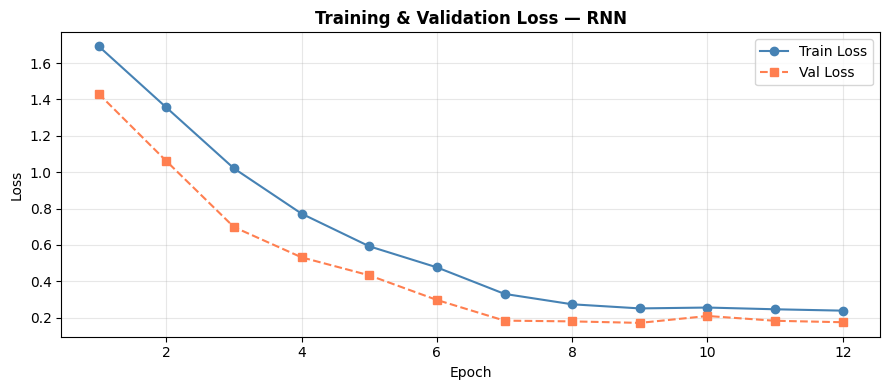


Test Accuracy: 0.9532 | Test Macro F1: 0.9344

 Training GRU
Epoch 01/15 | Train Loss: 1.2923 Acc: 0.4406 | Val Loss: 0.3291 Acc: 0.9005 F1: 0.8691 | 54.2s
Epoch 02/15 | Train Loss: 0.2841 Acc: 0.9058 | Val Loss: 0.1111 Acc: 0.9528 F1: 0.9332 | 54.3s
Epoch 03/15 | Train Loss: 0.1387 Acc: 0.9483 | Val Loss: 0.0871 Acc: 0.9565 F1: 0.9369 | 54.3s
Epoch 04/15 | Train Loss: 0.1051 Acc: 0.9547 | Val Loss: 0.0799 Acc: 0.9595 F1: 0.9405 | 54.1s
Epoch 05/15 | Train Loss: 0.0921 Acc: 0.9570 | Val Loss: 0.0766 Acc: 0.9594 F1: 0.9401 | 54.0s
Epoch 06/15 | Train Loss: 0.0866 Acc: 0.9584 | Val Loss: 0.0781 Acc: 0.9587 F1: 0.9391 | 54.2s
Epoch 07/15 | Train Loss: 0.0829 Acc: 0.9598 | Val Loss: 0.0763 Acc: 0.9589 F1: 0.9399 | 54.2s
Epoch 08/15 | Train Loss: 0.0803 Acc: 0.9604 | Val Loss: 0.0759 Acc: 0.9605 F1: 0.9416 | 54.5s
Epoch 09/15 | Train Loss: 0.0788 Acc: 0.9609 | Val Loss: 0.0740 Acc: 0.9611 F1: 0.9423 | 55.2s
Epoch 10/15 | Train Loss: 0.0773 Acc: 0.9614 | Val Loss: 0.0741 Acc: 0.9601 F1: 0.9

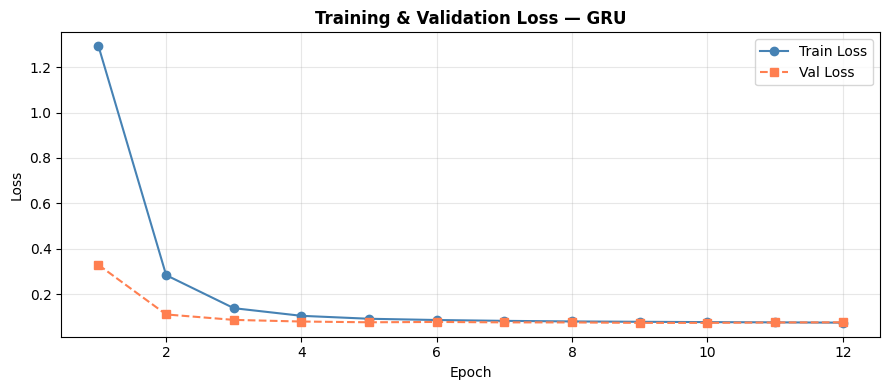


Test Accuracy: 0.9633 | Test Macro F1: 0.9452

 Training LSTM
Epoch 01/15 | Train Loss: 1.4380 Acc: 0.3533 | Val Loss: 0.8354 Acc: 0.7259 F1: 0.6570 | 62.5s
Epoch 02/15 | Train Loss: 0.5715 Acc: 0.7992 | Val Loss: 0.1848 Acc: 0.9349 F1: 0.9121 | 62.1s
Epoch 03/15 | Train Loss: 0.2224 Acc: 0.9292 | Val Loss: 0.1169 Acc: 0.9507 F1: 0.9296 | 62.7s
Epoch 04/15 | Train Loss: 0.1410 Acc: 0.9481 | Val Loss: 0.0921 Acc: 0.9549 F1: 0.9350 | 62.2s
Epoch 05/15 | Train Loss: 0.1115 Acc: 0.9535 | Val Loss: 0.0837 Acc: 0.9566 F1: 0.9349 | 62.9s
Epoch 06/15 | Train Loss: 0.1004 Acc: 0.9551 | Val Loss: 0.0820 Acc: 0.9564 F1: 0.9332 | 64.7s
Epoch 07/15 | Train Loss: 0.0935 Acc: 0.9569 | Val Loss: 0.0782 Acc: 0.9581 F1: 0.9387 | 63.0s
Epoch 08/15 | Train Loss: 0.0896 Acc: 0.9581 | Val Loss: 0.0779 Acc: 0.9591 F1: 0.9398 | 67.0s
Epoch 09/15 | Train Loss: 0.0866 Acc: 0.9590 | Val Loss: 0.0798 Acc: 0.9569 F1: 0.9370 | 62.3s
Epoch 10/15 | Train Loss: 0.0845 Acc: 0.9593 | Val Loss: 0.0769 Acc: 0.9593 F1: 0.

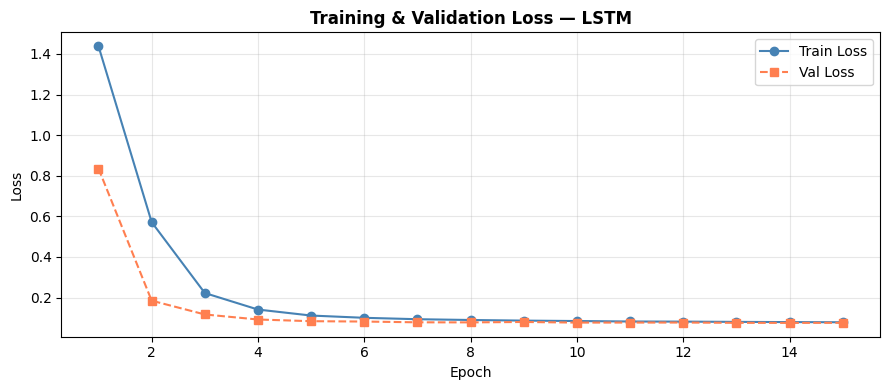


Test Accuracy: 0.9631 | Test Macro F1: 0.9448


In [30]:
# Shared hyperparameters for all RNN variants
RNN_HIDDEN_DIM = 256
RNN_NUM_LAYERS = 2
RNN_DROPOUT    = 0.3
RNN_LR         = 1e-4
RNN_EPOCHS     = 15
PATIENCE       = 3    # early stopping patience

criterion_rnn = nn.CrossEntropyLoss(weight=class_weights)

rnn_results = {}  # store metrics for comparison


def train_rnn_model(rnn_type: str):
    print(f"\n{'='*55}")
    print(f" Training {rnn_type}")
    print(f"{'='*55}")

    model = RNNClassifier(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=RNN_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        num_layers=RNN_NUM_LAYERS,
        dropout=RNN_DROPOUT,
        rnn_type=rnn_type,
        pretrained_embeddings=embedding_matrix,
        pad_idx=PAD_IDX
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=RNN_LR, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(1, RNN_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_epoch_rnn(model, train_loader_rnn, optimizer, criterion_rnn)
        val_loss, val_acc, val_f1 = eval_epoch_rnn(model, val_loader_rnn, criterion_rnn)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        print(f"Epoch {epoch:02d}/{RNN_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
              f"{elapsed:.1f}s")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}.")
                break

    # Restore best weights
    model.load_state_dict(best_state)

    # Plot training curves
    plot_training_curves(history, rnn_type)

    # Test evaluation
    test_loss, test_acc, test_f1 = eval_epoch_rnn(model, test_loader_rnn, criterion_rnn)
    print(f"\nTest Accuracy: {test_acc:.4f} | Test Macro F1: {test_f1:.4f}")

    # Save model
    torch.save(model.state_dict(), f'{rnn_type.lower()}_emotion.pt')

    rnn_results[rnn_type] = {
        'model': model,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'history': history
    }
    return model


rnn_model  = train_rnn_model('RNN')
gru_model  = train_rnn_model('GRU')
lstm_model = train_rnn_model('LSTM')

---
## 7. Train DistilBERT

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT...
Epoch 01/5 | Train Loss: 0.3138 Acc: 0.8866 | Val Loss: 0.0929 Acc: 0.9581 F1: 0.9381 | 1418.8s
Epoch 02/5 | Train Loss: 0.0874 Acc: 0.9595 | Val Loss: 0.0792 Acc: 0.9592 F1: 0.9384 | 1415.3s
Epoch 03/5 | Train Loss: 0.0776 Acc: 0.9628 | Val Loss: 0.0886 Acc: 0.9616 F1: 0.9429 | 1416.9s
Epoch 04/5 | Train Loss: 0.0681 Acc: 0.9667 | Val Loss: 0.0959 Acc: 0.9609 F1: 0.9415 | 1416.2s
Early stopping at epoch 4.


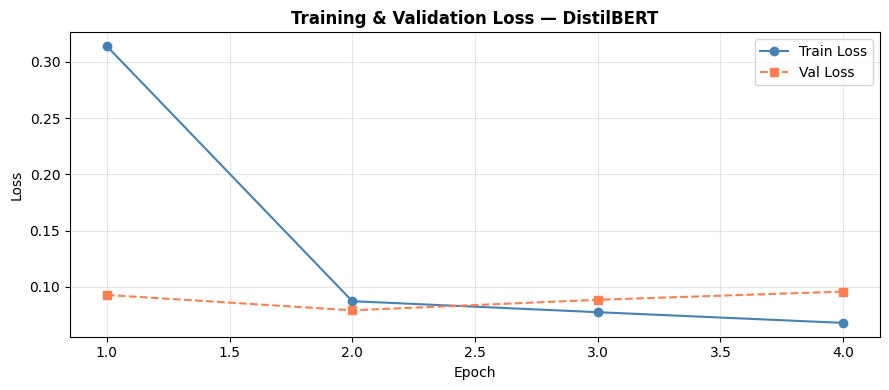


DistilBERT Test Accuracy: 0.9597 | Test Macro F1: 0.9397


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT saved to 'distilbert_emotion/'


In [32]:
BERT_EPOCHS = 5
BERT_LR     = 2e-5
PATIENCE_BERT = 2

bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_CLASSES
).to(DEVICE)

optimizer_bert = optim.AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)

total_steps = len(train_loader_bert) * BERT_EPOCHS
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion_bert = nn.CrossEntropyLoss(weight=class_weights)

bert_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss_bert = float('inf')
patience_counter_bert = 0
best_state_bert = None

print("Training DistilBERT...")
print('='*55)

for epoch in range(1, BERT_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch_bert(
        bert_model, train_loader_bert, optimizer_bert, scheduler_bert, criterion_bert
    )
    val_loss, val_acc, val_f1 = eval_epoch_bert(bert_model, val_loader_bert, criterion_bert)

    bert_history['train_loss'].append(train_loss)
    bert_history['val_loss'].append(val_loss)
    bert_history['train_acc'].append(train_acc)
    bert_history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{BERT_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
          f"{elapsed:.1f}s")

    if val_loss < best_val_loss_bert:
        best_val_loss_bert = val_loss
        best_state_bert = {k: v.clone() for k, v in bert_model.state_dict().items()}
        patience_counter_bert = 0
    else:
        patience_counter_bert += 1
        if patience_counter_bert >= PATIENCE_BERT:
            print(f"Early stopping at epoch {epoch}.")
            break

bert_model.load_state_dict(best_state_bert)
plot_training_curves(bert_history, 'DistilBERT')

# Test evaluation
test_loss_bert, test_acc_bert, test_f1_bert = eval_epoch_bert(
    bert_model, test_loader_bert, criterion_bert
)
print(f"\nDistilBERT Test Accuracy: {test_acc_bert:.4f} | Test Macro F1: {test_f1_bert:.4f}")

# Save
bert_model.save_pretrained('distilbert_emotion')
bert_tokenizer.save_pretrained('distilbert_emotion')
print("DistilBERT saved to 'distilbert_emotion/'")

---
## 8. Model Comparison

In [33]:
comparison = {
    'RNN':        (rnn_results['RNN']['test_acc'],  rnn_results['RNN']['test_f1']),
    'GRU':        (rnn_results['GRU']['test_acc'],  rnn_results['GRU']['test_f1']),
    'LSTM':       (rnn_results['LSTM']['test_acc'], rnn_results['LSTM']['test_f1']),
    'DistilBERT': (test_acc_bert, test_f1_bert)
}

comp_df = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in comparison.items()],
    columns=['Model', 'Test Accuracy', 'Test Macro F1']
).sort_values('Test Macro F1', ascending=False)

print("=== Model Comparison ===")
print(comp_df.to_string(index=False))

=== Model Comparison ===
     Model  Test Accuracy  Test Macro F1
       GRU       0.963285       0.945200
      LSTM       0.963132       0.944815
DistilBERT       0.959730       0.939701
       RNN       0.953179       0.934408


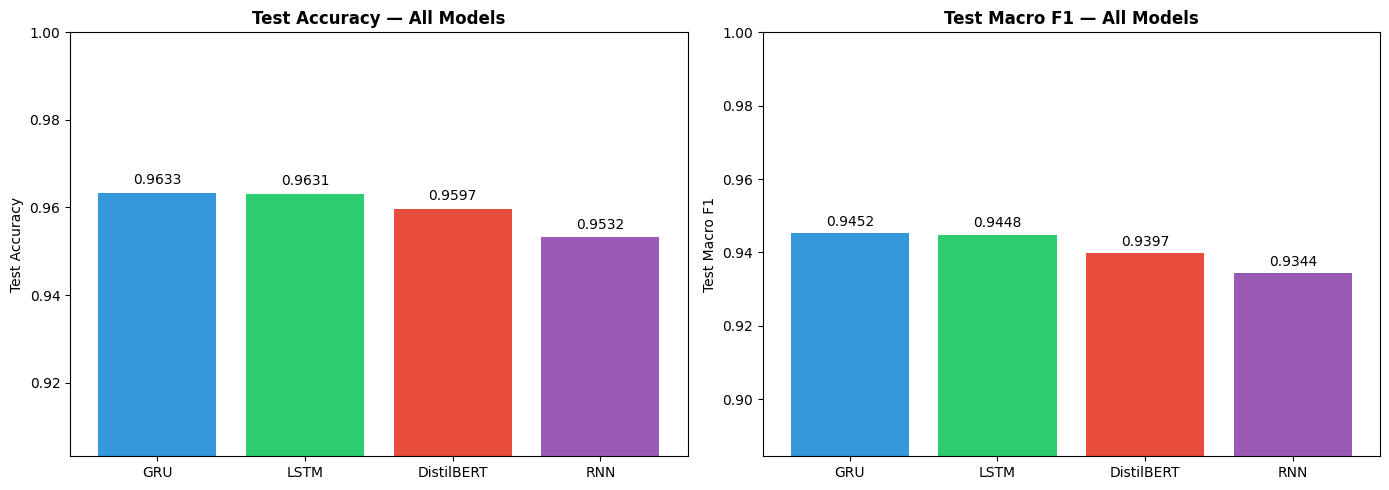

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, metric in zip(axes, ['Test Accuracy', 'Test Macro F1']):
    bars = ax.bar(comp_df['Model'], comp_df[metric], color=palette)
    ax.set_ylim(comp_df[metric].min() - 0.05, 1.0)
    ax.set_title(f'{metric} — All Models', fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('./artifacts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 All Training Curves on One Figure

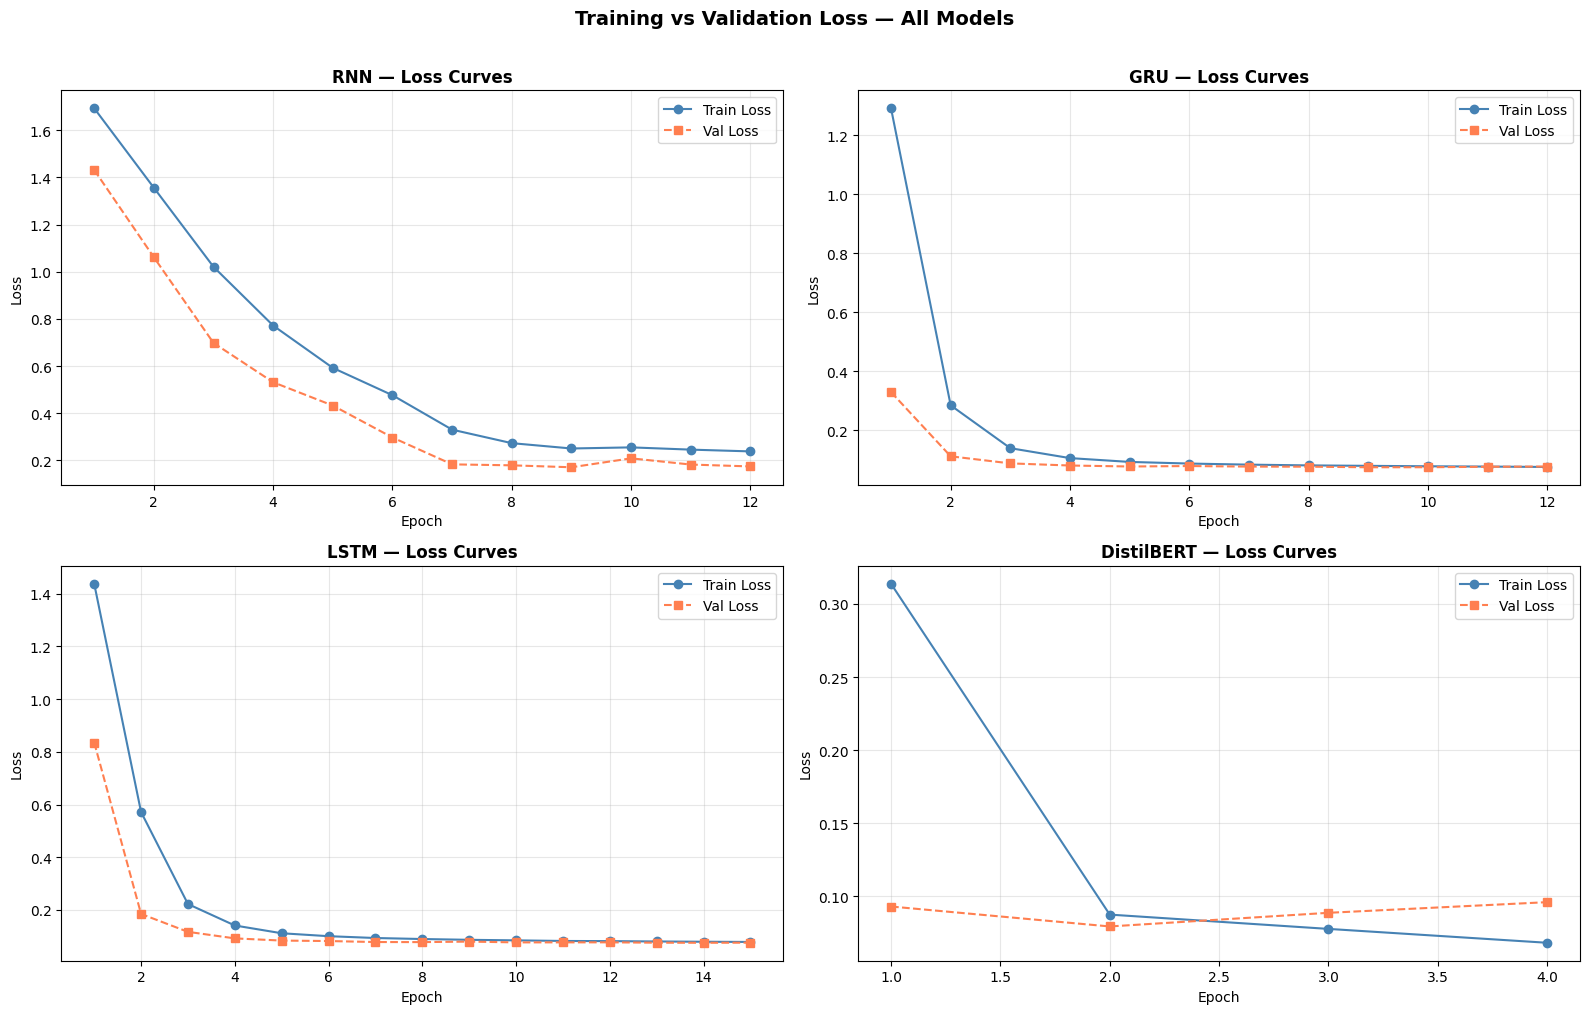

In [37]:
all_histories = {
    'RNN':        rnn_results['RNN']['history'],
    'GRU':        rnn_results['GRU']['history'],
    'LSTM':       rnn_results['LSTM']['history'],
    'DistilBERT': bert_history
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (name, hist) in zip(axes.flatten(), all_histories.items()):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], 'o-', color='steelblue', label='Train Loss')
    ax.plot(epochs, hist['val_loss'],   's--', color='coral',   label='Val Loss')
    ax.set_title(f'{name} — Loss Curves', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training vs Validation Loss — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./artifacts/all_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Best Model — Detailed Evaluation

In [38]:
best_model_name = comp_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Get predictions from best model
def get_all_preds(model, loader, is_bert=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        if is_bert:
            for batch in loader:
                input_ids      = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels         = batch['label']
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.numpy())
        else:
            for texts, labels in loader:
                texts = texts.to(DEVICE)
                logits = model(texts)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


if best_model_name == 'DistilBERT':
    best_model = bert_model
    y_true, y_pred = get_all_preds(best_model, test_loader_bert, is_bert=True)
else:
    best_model = rnn_results[best_model_name]['model']
    y_true, y_pred = get_all_preds(best_model, test_loader_rnn, is_bert=False)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=list(label2emotion.values())))

Best model: GRU

=== Classification Report ===
              precision    recall  f1-score   support

     sadness       1.00      0.97      0.98      5925
         joy       1.00      0.95      0.97      6755
        love       0.84      1.00      0.91      1470
       anger       0.94      0.98      0.96      2736
        fear       0.95      0.94      0.94      2184
    surprise       0.83      1.00      0.90       622

    accuracy                           0.96     19692
   macro avg       0.92      0.97      0.95     19692
weighted avg       0.97      0.96      0.96     19692



### 9.1 Confusion Matrix

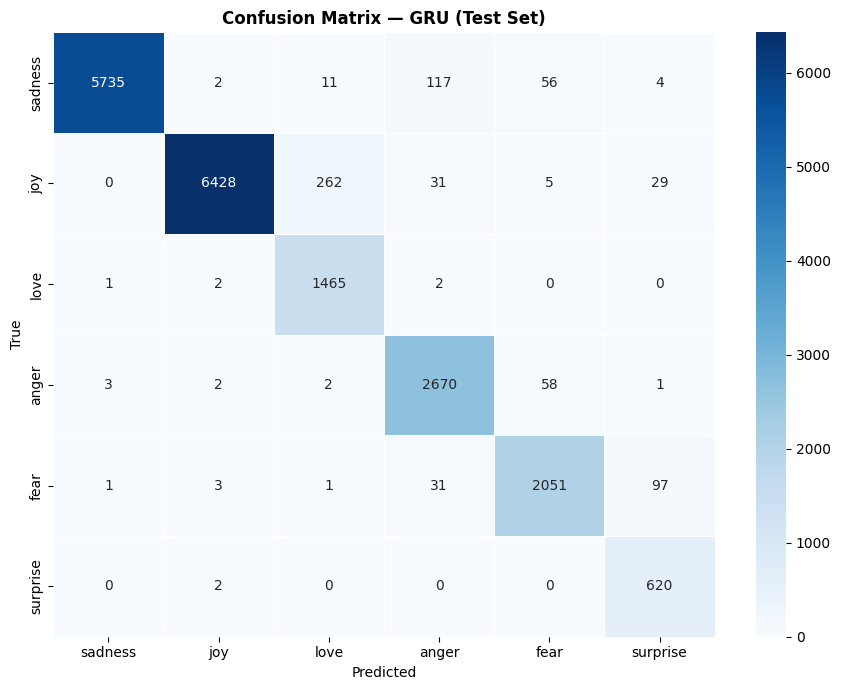

In [39]:
cm = confusion_matrix(y_true, y_pred)
emotion_names = list(label2emotion.values())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=emotion_names, yticklabels=emotion_names,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name} (Test Set)', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('./artifacts/confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Per-Class F1 Score

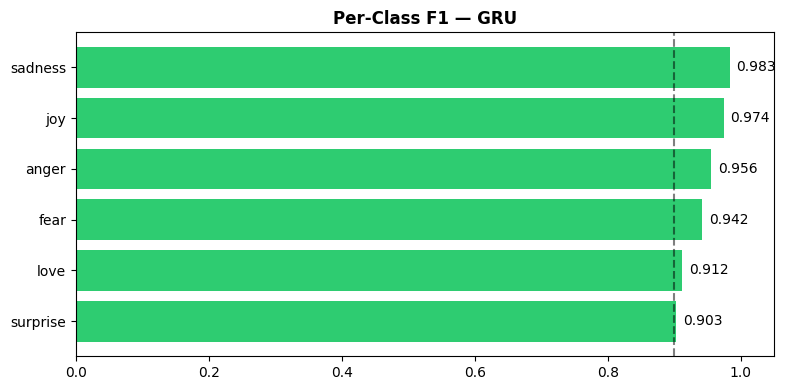

In [41]:
per_class_f1 = f1_score(y_true, y_pred, average=None)
f1_df = pd.DataFrame({'Emotion': emotion_names, 'F1': per_class_f1}).sort_values('F1')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if f < 0.90 else '#2ecc71' for f in f1_df['F1']]
ax.barh(f1_df['Emotion'], f1_df['F1'], color=colors)
ax.set_xlim(0, 1.05)
ax.axvline(0.90, color='black', linestyle='--', alpha=0.5)
ax.set_title(f'Per-Class F1 — {best_model_name}', fontweight='bold')
for i, (e, f) in enumerate(zip(f1_df['Emotion'], f1_df['F1'])):
    ax.text(f + 0.01, i, f'{f:.3f}', va='center')
plt.tight_layout()
plt.savefig('./artifacts/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Inference Demo

In [47]:
def predict_emotion(text: str, model, is_bert: bool) -> str:
    model.eval()
    with torch.no_grad():
        if is_bert:
            encoding = bert_tokenizer(
                text, max_length=BERT_MAX_LEN,
                padding='max_length', truncation=True, return_tensors='pt'
            )
            input_ids      = encoding['input_ids'].to(DEVICE)
            attention_mask = encoding['attention_mask'].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        else:
            clean = clean_text(text)
            indices = text_to_indices(clean, word2idx, MAX_LEN)
            tensor  = torch.tensor([indices], dtype=torch.long).to(DEVICE)
            logits  = model(tensor)

        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred  = probs.argmax()

    return label2emotion[pred], {label2emotion[i]: float(p) for i, p in enumerate(probs)}


is_bert = best_model_name == 'DistilBERT'

test_sentences = [
    "I feel so hopeless and empty, nothing brings me joy anymore.",
    "I'm so excited about my progress today, feeling great!",
    "I'm terrified of what might happen next.",
    "I love spending time with my family, it warms my heart.",
    "This situation makes me so angry, I can't stand it.",
    "I didn't expect that at all, completely caught off guard."
]

print("=== Emotion Detection Demo ===")
for sent in test_sentences:
    emotion, probs = predict_emotion(sent, best_model, is_bert)
    top_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"\nText    : {sent}")
    print(f"Predicted: {emotion.upper()}")
    print(f"Top 3   : {', '.join([f'{e}({p:.2f})' for e, p in top_probs])}")

=== Emotion Detection Demo ===

Text    : I feel so hopeless and empty, nothing brings me joy anymore.
Predicted: SADNESS
Top 3   : sadness(1.00), anger(0.00), surprise(0.00)

Text    : I'm so excited about my progress today, feeling great!
Predicted: JOY
Top 3   : joy(0.99), anger(0.00), sadness(0.00)

Text    : I'm terrified of what might happen next.
Predicted: FEAR
Top 3   : fear(1.00), sadness(0.00), anger(0.00)

Text    : I love spending time with my family, it warms my heart.
Predicted: SADNESS
Top 3   : sadness(0.33), anger(0.30), joy(0.28)

Text    : This situation makes me so angry, I can't stand it.
Predicted: ANGER
Top 3   : anger(0.95), fear(0.02), sadness(0.02)

Text    : I didn't expect that at all, completely caught off guard.
Predicted: FEAR
Top 3   : fear(0.70), anger(0.24), sadness(0.04)


---
## 11. Download Results

In [45]:
from IPython.display import FileLink
import shutil

shutil.make_archive('artifacts', 'zip', 'artifacts')
FileLink(r'artifacts.zip')

/content/artifacts.zip

In [46]:
shutil.make_archive('distilbert_emotion', 'zip', 'distilbert_emotion')
FileLink(r'distilbert_emotion.zip')

/content/distilbert_emotion.zip

---
## 12. Summary & Conclusions

| Model | Test Accuracy | Test Macro F1 | Notes |
|---|---|---|---|
| Vanilla RNN | 95.32% | 0.9344 | Baseline; struggles with long-range dependencies |
| **GRU** | 96.33% | 0.9452 | **Best recurrent model**; faster than LSTM |
| LSTM | 96.31% | 0.9448 | Better than RNN; handles long dependencies well |
| DistilBERT | 95.97% | 0.9397 | Transformer; pretrained representations are good but may need to reduce the learning rate |

### Key Observations
- Class imbalance (`joy` >> `surprise`) was handled via **weighted cross-entropy loss**
- GloVe embeddings gave RNN models a strong head start over random initialization
- DistilBERT benefits from contextualized representations and subword tokenization
- Hardest emotions to distinguish: `surprise` and `love` (due to few samples)
